## Testing docker images

Done:
* troubleshot docker images
* get_value

now:
* set_value


<!-- * bmi-plugin implementation
 bmi-model implementation
current date: 2026-02-13

- [x] Troubleshot Docker images
- [x] get_value

- [x] text -->



In [1]:
# docker build -t ewatercycle-pcr-16feb .
# docker save -o ewatercycle_pcr_16feb.tar ewatercycle-pcr-16feb
# apptainer build ewatercycle_pcr_16feb.sif docker-archive://ewatercycle_pcr_16feb.tar

In [2]:
import sys
from pathlib import Path

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.observation.grdc
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage
from rich import print

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
from cartopy import crs
from cartopy import feature as cfeature
from matplotlib.colors import LogNorm
from tqdm.notebook import tqdm

from src.aral import load_grdc_monthly
from src.constants import STATIONS_PCR
from src.paths import FORCING_PCRGLOB, GRDC, INI_FILES, LOAD_PCR, PCR_GLOBAL_PARAMS, PCR_TAIL

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
STATIONS_PCR

{'Chatly': {'lat': 42.2, 'lon': 60.2},
 'Kazalinsk': {'lat': 45.7, 'lon': 62.12},
 'Kerki': {'lat': 37.83, 'lon': 65.25},
 'Tyumen-Aryk': {'lat': 43.95, 'lon': 67.05},
 'Karaozek': {'lat': 44.95, 'lon': 65.27}}

In [4]:
pcr_glob_directory = PCR_GLOBAL_PARAMS  # GlobalOption uit .ini
prepared_pcr_forcing = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL


parameter_set_test = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "test_container_images.ini",
    target_model="pcrglobwb",
    supported_model_versions={"16feb"},
)

forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_pcr_forcing,
)

In [5]:
my_image = ContainerImage("/home/avandervee3/ewatercycle_pcr_16feb.sif")
my_image.version

'16feb'

In [6]:
reference = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)


print(reference)

PCRGlobWB(
    parameter_set=ParameterSet(
        name='custom_parameter_set',
        directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
        config=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_i
n_progress/model_runs/pcrglobwb/ini_files/test_container_images.ini'),
        doi='N/A',
        target_model='pcrglobwb',
        supported_model_versions={'16feb'},
        downloader=None
    ),
    forcing=PCRGlobWBForcing(
        start_time='1940-01-01T00:00:00Z',
        end_time='1960-12-31T00:00:00Z',
        directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/wor
k_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script'),
        shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'),
        filenames={},
        precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-1960_AralSea_basin.nc',
        temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-1960_AralSea_basin.nc'
    )
)

In [7]:
experiment_start_date = "1950-01-01T00:00:00Z"
experiment_end_date = "1950-01-10T00:00:00Z"

In [8]:
reference_config, reference_dir = reference.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)
reference_config, reference_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260217_140233/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260217_140233')

In [9]:
print(reference.parameters)

refence_para = reference.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-01-01T00:00:00Z'), ('end_time', '1950-01-10T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 9

In [10]:
print("Using config:", reference_config)

Using config: 
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/explo
ration/Image_tests/pcrglobwb_20260217_140233/pcrglobwb_ewatercycle.ini

In [11]:
reference.initialize(reference_config)

In [12]:
time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
stations_timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk"]
)
stations_timeseries.head()


stations_timeseries_getvalue = stations_timeseries.copy()
stations_timeseries_setvalue = stations_timeseries.copy()
stations_timeseries_reference = stations_timeseries.copy()

In [13]:
for _ in tqdm(range(number_of_days), desc="Running model"):
    reference.update()

print("Model run finished!")

Running model:   0%|          | 0/9 [00:00<?, ?it/s]

Model run finished!

In [14]:
soil_moisture = reference.get_value_as_xarray("channel_storage")

# Copy the field and manually overwrite a random part of the domain
irrigated_soil_moisture = soil_moisture.copy()
irrigated_soil_moisture[100:200, 100:200] += 100

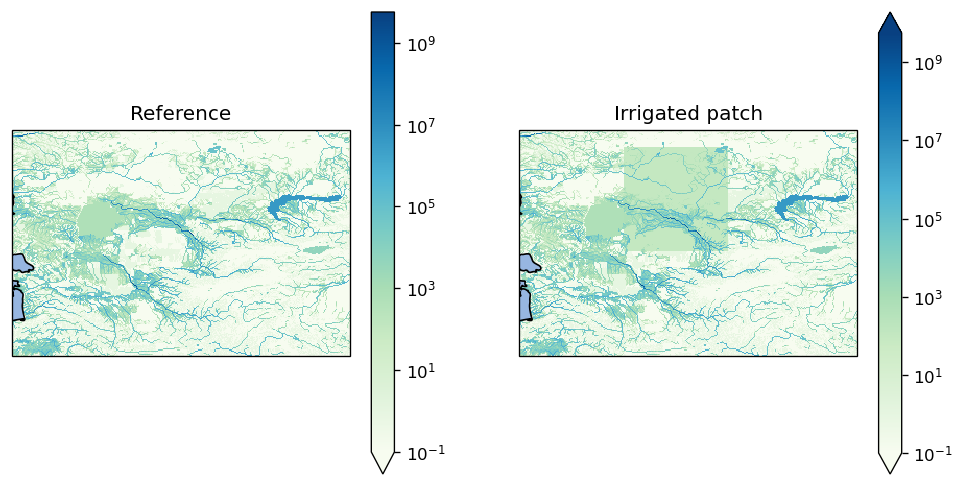

In [15]:
fig = plt.figure(figsize=(10, 5), dpi=120)
left_axes = fig.add_subplot(121, projection=crs.PlateCarree())
right_axes = fig.add_subplot(122, projection=crs.PlateCarree())

# Replace non-positive values with a small number
soil_moisture_safe = soil_moisture.where(soil_moisture > 0, 1e-6)
irrigated_soil_moisture_safe = irrigated_soil_moisture.where(irrigated_soil_moisture > 0, 1e-6)

soil_moisture_safe.plot(
    ax=left_axes, cmap="GnBu", norm=LogNorm(vmin=0.1, vmax=soil_moisture_safe.max())
)

irrigated_soil_moisture_safe.plot(
    ax=right_axes, cmap="GnBu", norm=LogNorm(vmin=0.1, vmax=soil_moisture_safe.max())
)
# Decoration
left_axes.set_title("Reference")
right_axes.set_title("Irrigated patch")

for axes in [left_axes, right_axes]:
    axes.add_feature(cfeature.OCEAN, zorder=2)
    # axes.add_feature(cfeature.RIVERS, zorder=2, color="k")
    axes.coastlines(zorder=3)

## Set_value

In [16]:
set_value_start_date = "1949-12-01T00:00:00Z"
set_value_end_date = "1950-01-31T00:00:00Z"

In [17]:
test_set_value = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

In [18]:
test_set_value_config, test_set_value_dir = test_set_value.setup(
    start_time=set_value_start_date, end_time=set_value_end_date, max_spinups_in_years=1
)
test_set_value_config, test_set_value_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260217_140620/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260217_140620')

In [19]:
print(reference.parameters)

test_get_value_para = test_set_value.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(set_value_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(set_value_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-01-01T00:00:00Z'), ('end_time', '1950-01-10T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 61

In [20]:
test_set_value.initialize(test_set_value_config)

In [21]:
for _ in tqdm(range(number_of_days), desc="Running model"):
    test_set_value.update()

    # update  field
    test_variable = test_set_value.get_value_as_xarray(
        "channel_storage",
    )
    test_values = test_variable.values.copy()

    # Modify in-place
    test_values[100:200, 100:200] += 10000
    # test_variable[100:200,100:200] = test_variable[100:200,100:200] + 100
    # test_variable[100:200,100:200] = 1
    # print(test_variable.dtype)
    test_set_value.set_value("channel_storage", test_values.flatten())

    # Track discharge at station locations
    time = test_set_value.time_as_isostr

    for station_name, coords in STATIONS_PCR.items():
        discharge = test_set_value.get_value_at_coords(
            "discharge",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        stations_timeseries_setvalue.loc[time, station_name] = discharge[0]

    # test_values = test_get_value.get_value("discharge")
    # print(f"max = {np.max(test_values)}")

#     discharge_at_station = test_get_value.get_value_at_coords(
#     "discharge",
#     lat=[lat],
#     lon=[lon]
# )


# print(type(test_values))
print("Model run finished!")

# print(type(discharge_at_Chatly))

Running model:   0%|          | 0/61 [00:00<?, ?it/s]

Model run finished!

## test get value

bmi implementation

In [22]:
get_value_experiment_start_date = "1949-12-01T00:00:00Z"
get_value_experiment_end_date = "1950-01-31T00:00:00Z"

In [23]:
test_get_value = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

In [24]:
test_get_value_config, test_get_value_dir = test_get_value.setup(
    start_time=get_value_experiment_start_date,
    end_time=get_value_experiment_end_date,
    max_spinups_in_years=1,
)
test_get_value_config, test_get_value_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260217_141538/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260217_141538')

In [25]:
print(reference.parameters)

test_get_value_para = test_get_value.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(get_value_experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(get_value_experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-01-01T00:00:00Z'), ('end_time', '1950-01-10T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 61

In [26]:
test_get_value.initialize(test_get_value_config)

In [27]:
for _ in tqdm(range(number_of_days), desc="Running model"):
    test_get_value.update()

    # Track discharge at station locations
    time = test_get_value.time_as_isostr

    for station_name, coords in STATIONS_PCR.items():
        discharge = test_get_value.get_value_at_coords(
            "discharge",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        stations_timeseries_getvalue.loc[time, station_name] = discharge[0]

    # test_values = test_get_value.get_value("discharge")
    # print(f"max = {np.max(test_values)}")

#     discharge_at_station = test_get_value.get_value_at_coords(
#     "discharge",
#     lat=[lat],
#     lon=[lon]
# )


# print(type(test_values))
print("Model run finished!")

# print(type(discharge_at_Chatly))

Running model:   0%|          | 0/61 [00:00<?, ?it/s]

Model run finished!

In [28]:
grdc_station_id = "2817100"
data_home = GRDC / "Daily"

observations = ewatercycle.observation.grdc.get_grdc_data(
    station_id=grdc_station_id,
    start_time="1900-01-01T00:00:00Z",  # or: model_instance.start_time_as_isostr
    end_time="1990-12-15T00:00:00Z",
    data_home=data_home,
)
observations

<xarray.Dataset> Size: 223kB
Dimensions:              (time: 13880)
Coordinates:
  * time                 (time) datetime64[ns] 111kB 1936-01-01 ... 1973-12-31
    id                   int64 8B 2817100
Data variables:
    streamflow           (time) float64 111kB 688.0 664.0 614.0 ... 153.0 158.0
    area                 float64 8B 4.5e+05
    country              <U2 8B 'UZ'
    geo_x                float64 8B 59.7
    geo_y                float64 8B 42.28
    geo_z                float64 8B 72.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U6 24B 'CHATLY'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2817100_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

In [29]:
Syr_kaza = load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Amu_chatly = load_grdc_monthly(2817100, name="Amu Darya Chatly")

In [30]:
# stations_timeseries_getvalue.loc["1950"][["Karaozek"]].plot(label = "get_value")
# stations_timeseries_setvalue.loc["1950"][["Karaozek"]].plot(label = "set_value")

# #stations_timeseries_getvalue.loc["1950"][["Kerki","Chatly"]].plot()


# #observations.sel(time="1950")["streamflow"].plot(label = "GRDC-Chatly")
# plt.legend()
# #stations_timeseries.plot()

<Axes: xlabel='time'>

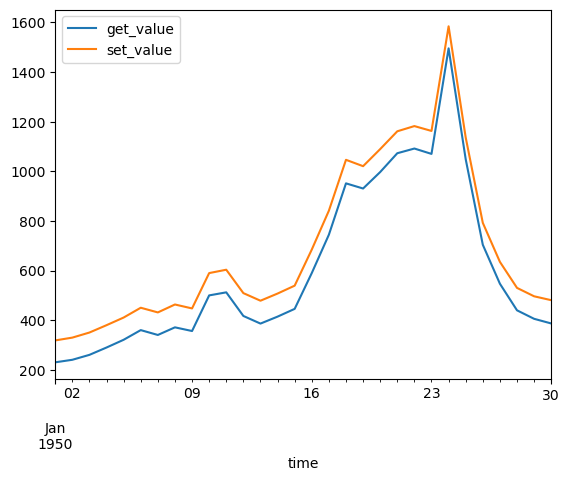

In [31]:
combined = pd.concat(
    [
        stations_timeseries_getvalue.loc["1950", ["Karaozek"]].rename(
            columns={"Karaozek": "get_value"}
        ),
        stations_timeseries_setvalue.loc["1950", ["Karaozek"]].rename(
            columns={"Karaozek": "set_value"}
        ),
    ],
    axis=1,
)

combined.plot()

<function matplotlib.pyplot.show(close=None, block=None)>

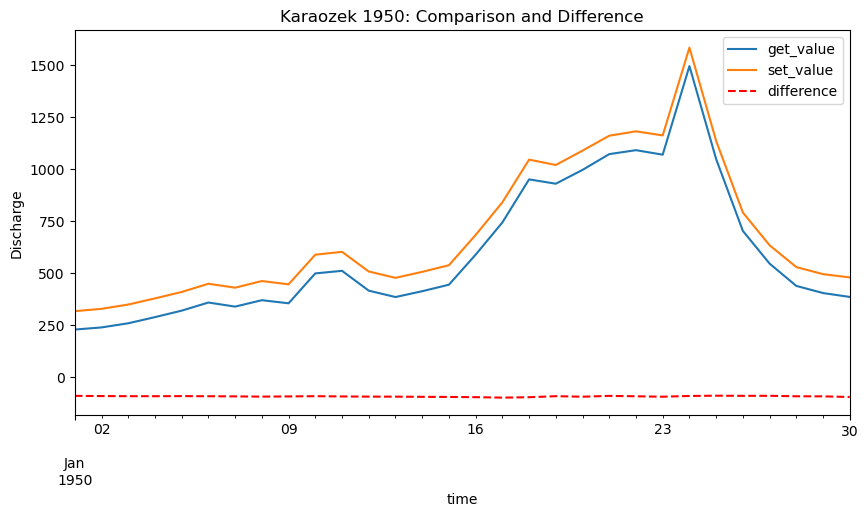

In [32]:
# Compute difference: get_value - set_value
combined["difference"] = combined["get_value"] - combined["set_value"]

# Plot
ax = combined[["get_value", "set_value"]].plot(figsize=(10, 5), label=["get_value", "set_value"])
combined["difference"].plot(ax=ax, style="--", color="red", label="difference")

ax.set_ylabel("Discharge")
ax.set_title("Karaozek 1950: Comparison and Difference")
ax.legend()
plt.show

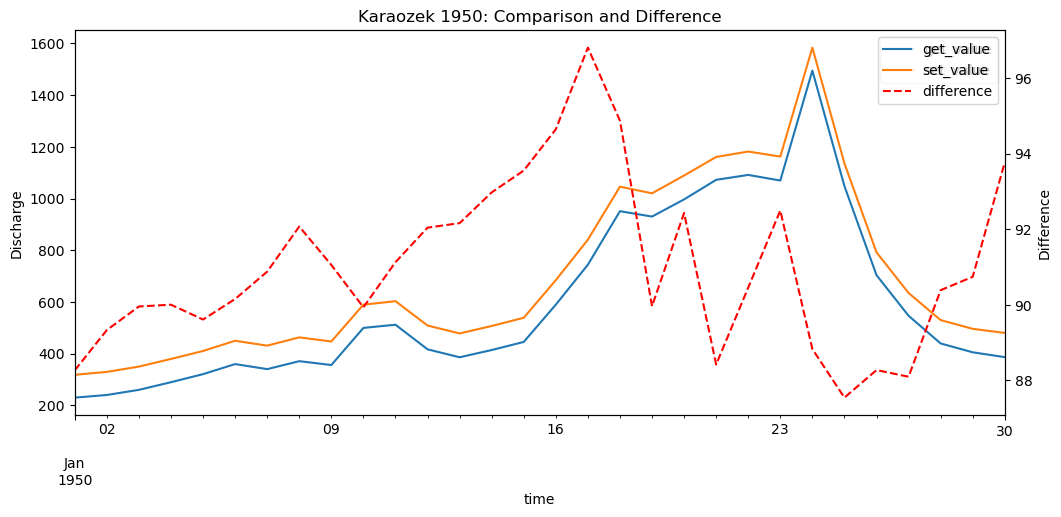

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine the two series for 1950
combined = pd.concat(
    [
        stations_timeseries_getvalue.loc["1950", ["Karaozek"]].rename(
            columns={"Karaozek": "get_value"}
        ),
        stations_timeseries_setvalue.loc["1950", ["Karaozek"]].rename(
            columns={"Karaozek": "set_value"}
        ),
    ],
    axis=1,
)

# Compute the difference
combined["difference"] = combined["set_value"] - combined["get_value"]

# Create main plot for get_value and set_value
fig, ax = plt.subplots(figsize=(12, 5))
combined[["get_value", "set_value"]].plot(ax=ax)
ax.set_ylabel("Discharge")
ax.set_title("Karaozek 1950: Comparison and Difference")

# Plot difference on secondary y-axis
ax2 = ax.twinx()
combined["difference"].plot(ax=ax2, color="red", linestyle="--", label="difference")
ax2.set_ylabel("Difference")

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")

plt.show()

In [34]:
reference.finalize()
test_get_value.finalize()
test_set_value.finalize()